In [1]:
import numpy as np
import matplotlib.pyplot as plt
from h5 import HDFArchive
from triqs.gf import *
from triqs.plot.mpl_interface import *

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'
plt.rc('font', size=12)


In [13]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
f_cthyb = f"{data_loc}/cthyb_lambda--0.01-U-4.0_b-10.0_nw-1000000_mins-150.h5"
f_ctseg = f"{data_loc}/spin_spin_ctseg_lambda--0.01-U-4.0_b-10.0.h5"

with HDFArchive(f_cthyb, "r") as A:
    G_tau_hyb = A["G_tau"]
    Sz_hyb = A["O_tau"]

with HDFArchive(f_ctseg, "r") as A:
    G_tau_seg = A["G_tau"]
    nn_seg = A["nn_tau"]


Cannot open the HDF file /home/andrewhardy/Documents/Data/CTHYB_Data/cthyb_lambda--0.01-U-4.0_b-10.0_nw-1000000_mins-150.h5


HDF5-DIAG: Error detected in HDF5 (1.10.10) thread 1:
  #000: ../../../src/H5F.c line 412 in H5Fopen(): unable to open file
    major: File accessibility
    minor: Unable to open file
  #001: ../../../src/H5Fint.c line 1655 in H5F_open(): unable to open file: time = Thu May  7 14:16:39 2026
, name = '/home/andrewhardy/Documents/Data/CTHYB_Data/cthyb_lambda--0.01-U-4.0_b-10.0_nw-1000000_mins-150.h5', tent_flags = 0
    major: File accessibility
    minor: Unable to open file
  #002: ../../../src/H5FD.c line 722 in H5FD_open(): open failed
    major: Virtual File Layer
    minor: Unable to initialize object
  #003: ../../../src/H5FDsec2.c line 351 in H5FD__sec2_open(): unable to open file: name = '/home/andrewhardy/Documents/Data/CTHYB_Data/cthyb_lambda--0.01-U-4.0_b-10.0_nw-1000000_mins-150.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0
    major: File accessibility
    minor: Unable to open file


RuntimeError: .. Error occurred at Thu May  7 14:16:39 2026

.. Error .. in calling C++ overload of constructor :
.. (no C++ name)(std::string name, char mode) -> 
.. C++ error was : 
Opening/Creating the file /home/andrewhardy/Documents/Data/CTHYB_Data/cthyb_lambda--0.01-U-4.0_b-10.0_nw-1000000_mins-150.h5 failed

In [11]:
G_tau_hyb["up"]

Green's Function G_tau_up with mesh Imaginary time mesh with beta = 10, statistics = Fermion, N = 4096 and target_shape (1, 1): 

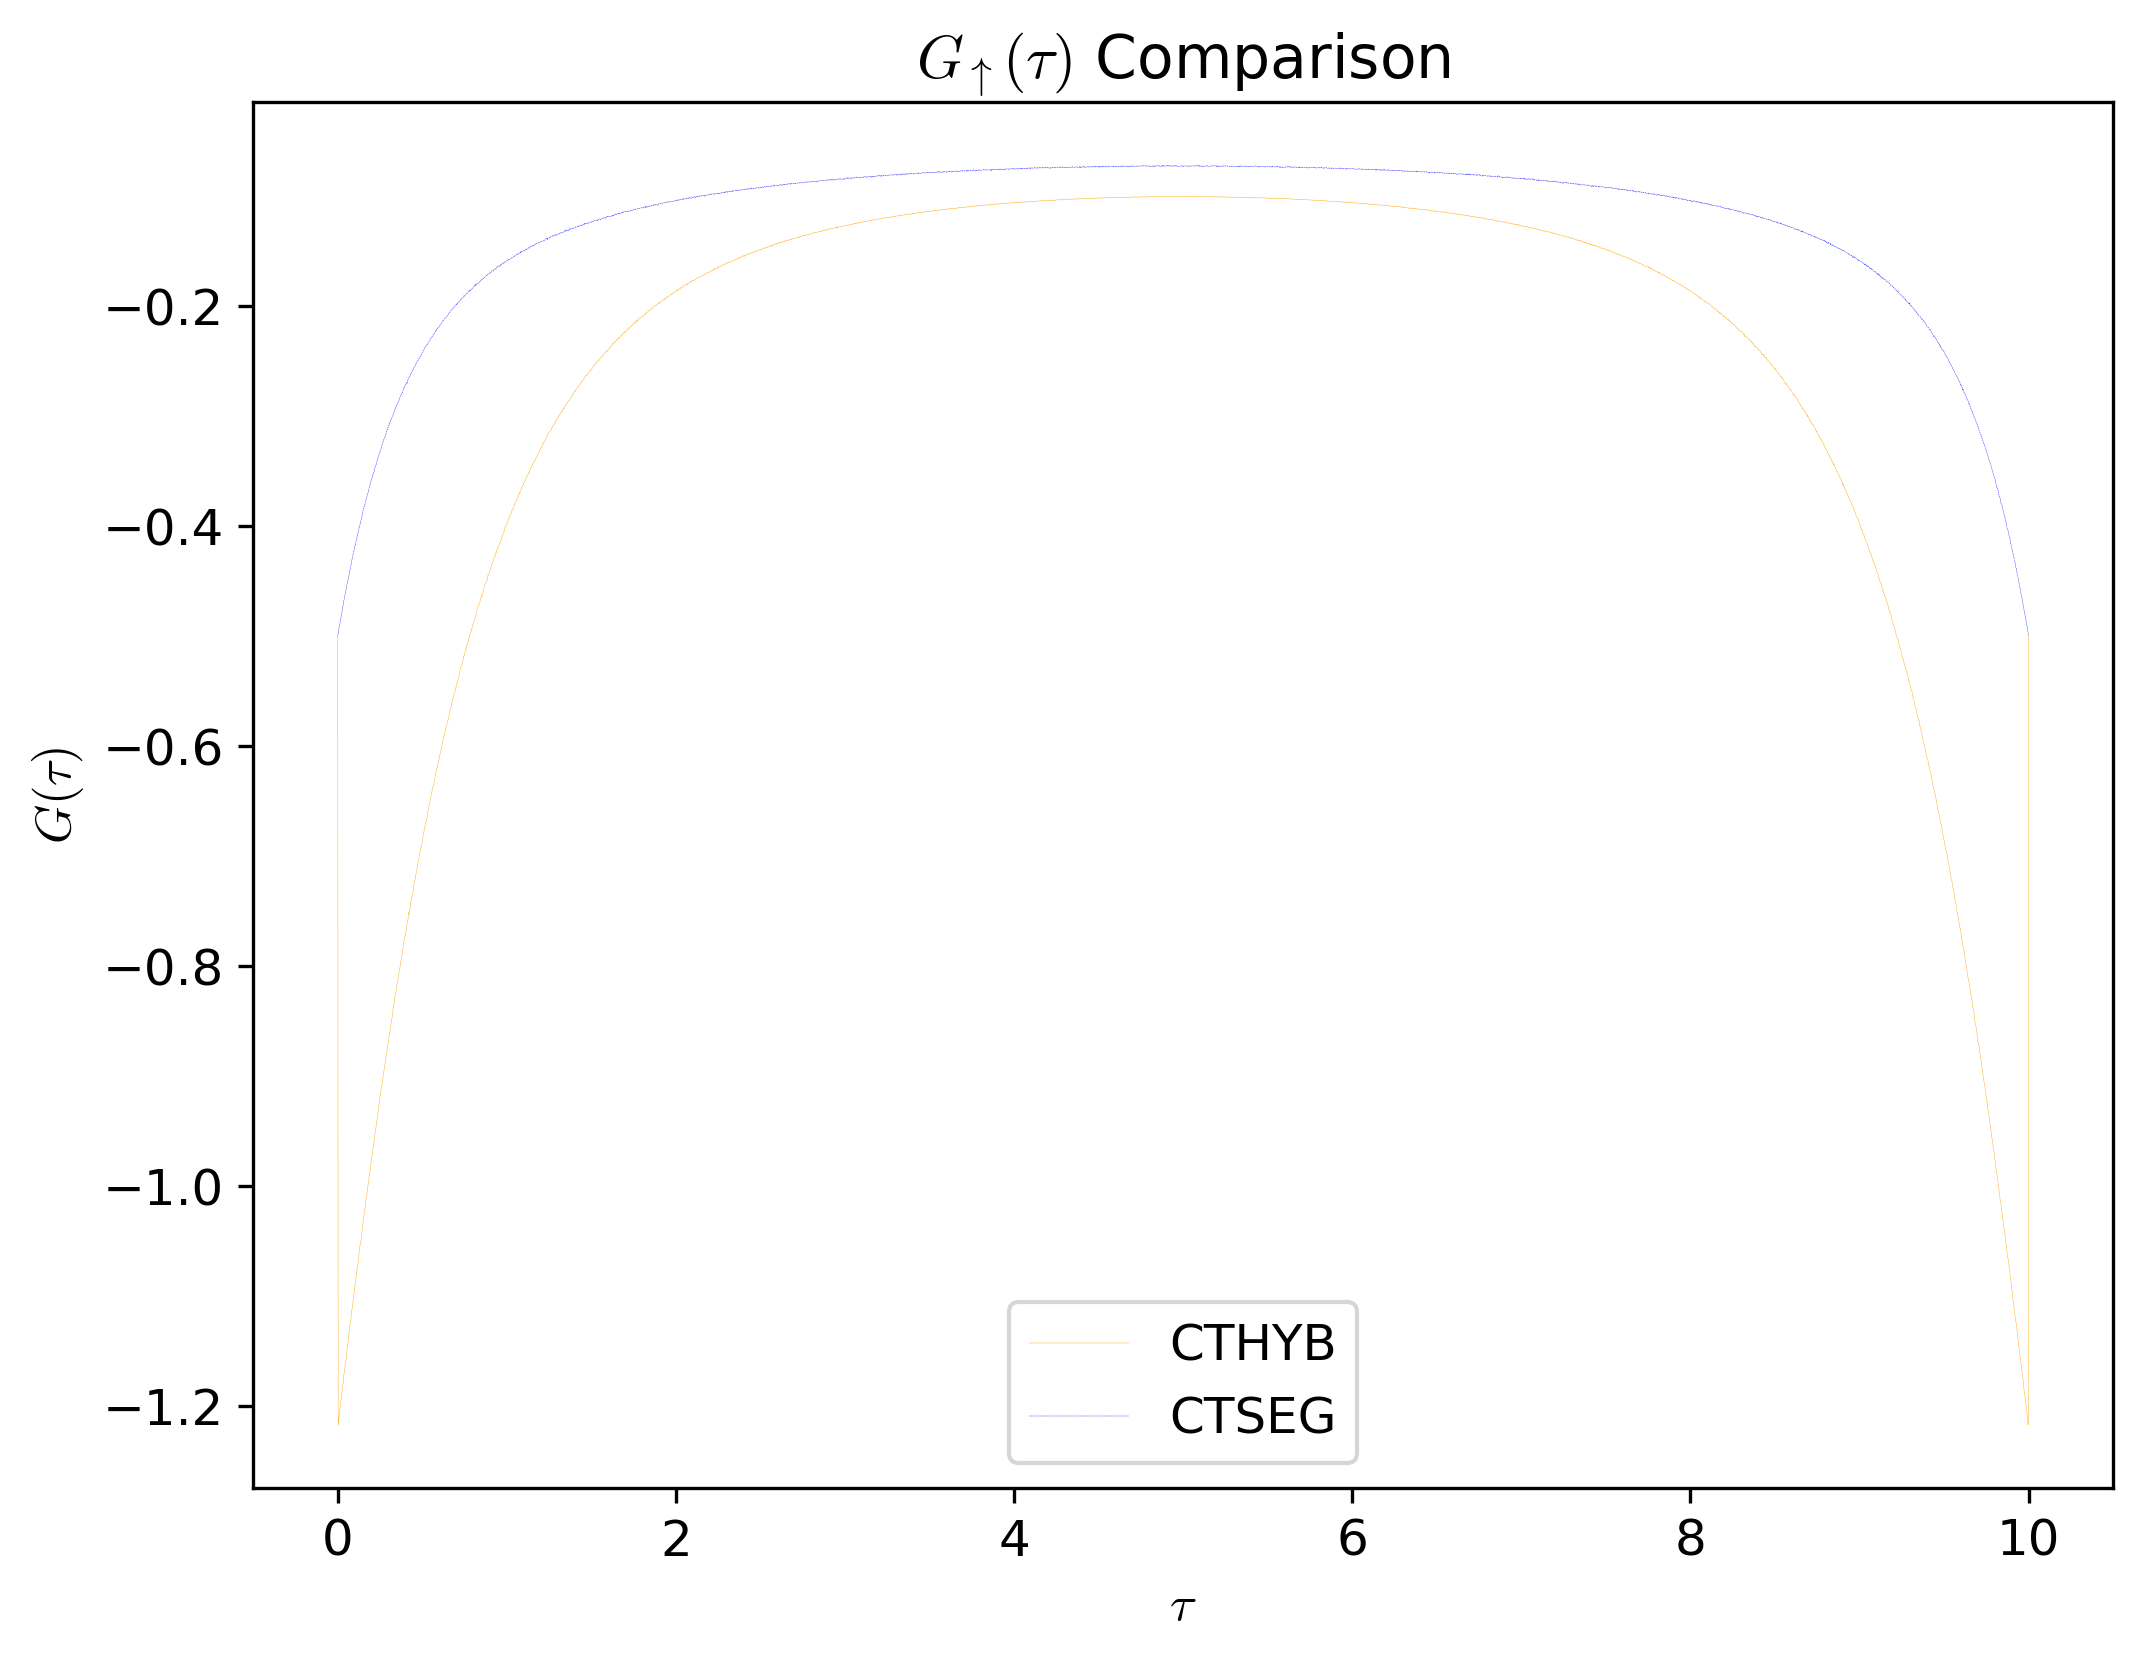

In [ ]:
plt.figure(figsize=(8, 6))
oplot(G_tau_hyb["up"].real, color="orange", linewidth=2.0, label="CTHYB")
oplot(G_tau_seg["up"].real, color="blue", linewidth=2.0, label="CTSEG", linestyle="--")
plt.title(r"$G_\uparrow(\tau)$ Comparison")
plt.ylabel(r"$G(\tau)$")
plt.legend()
plt.show()


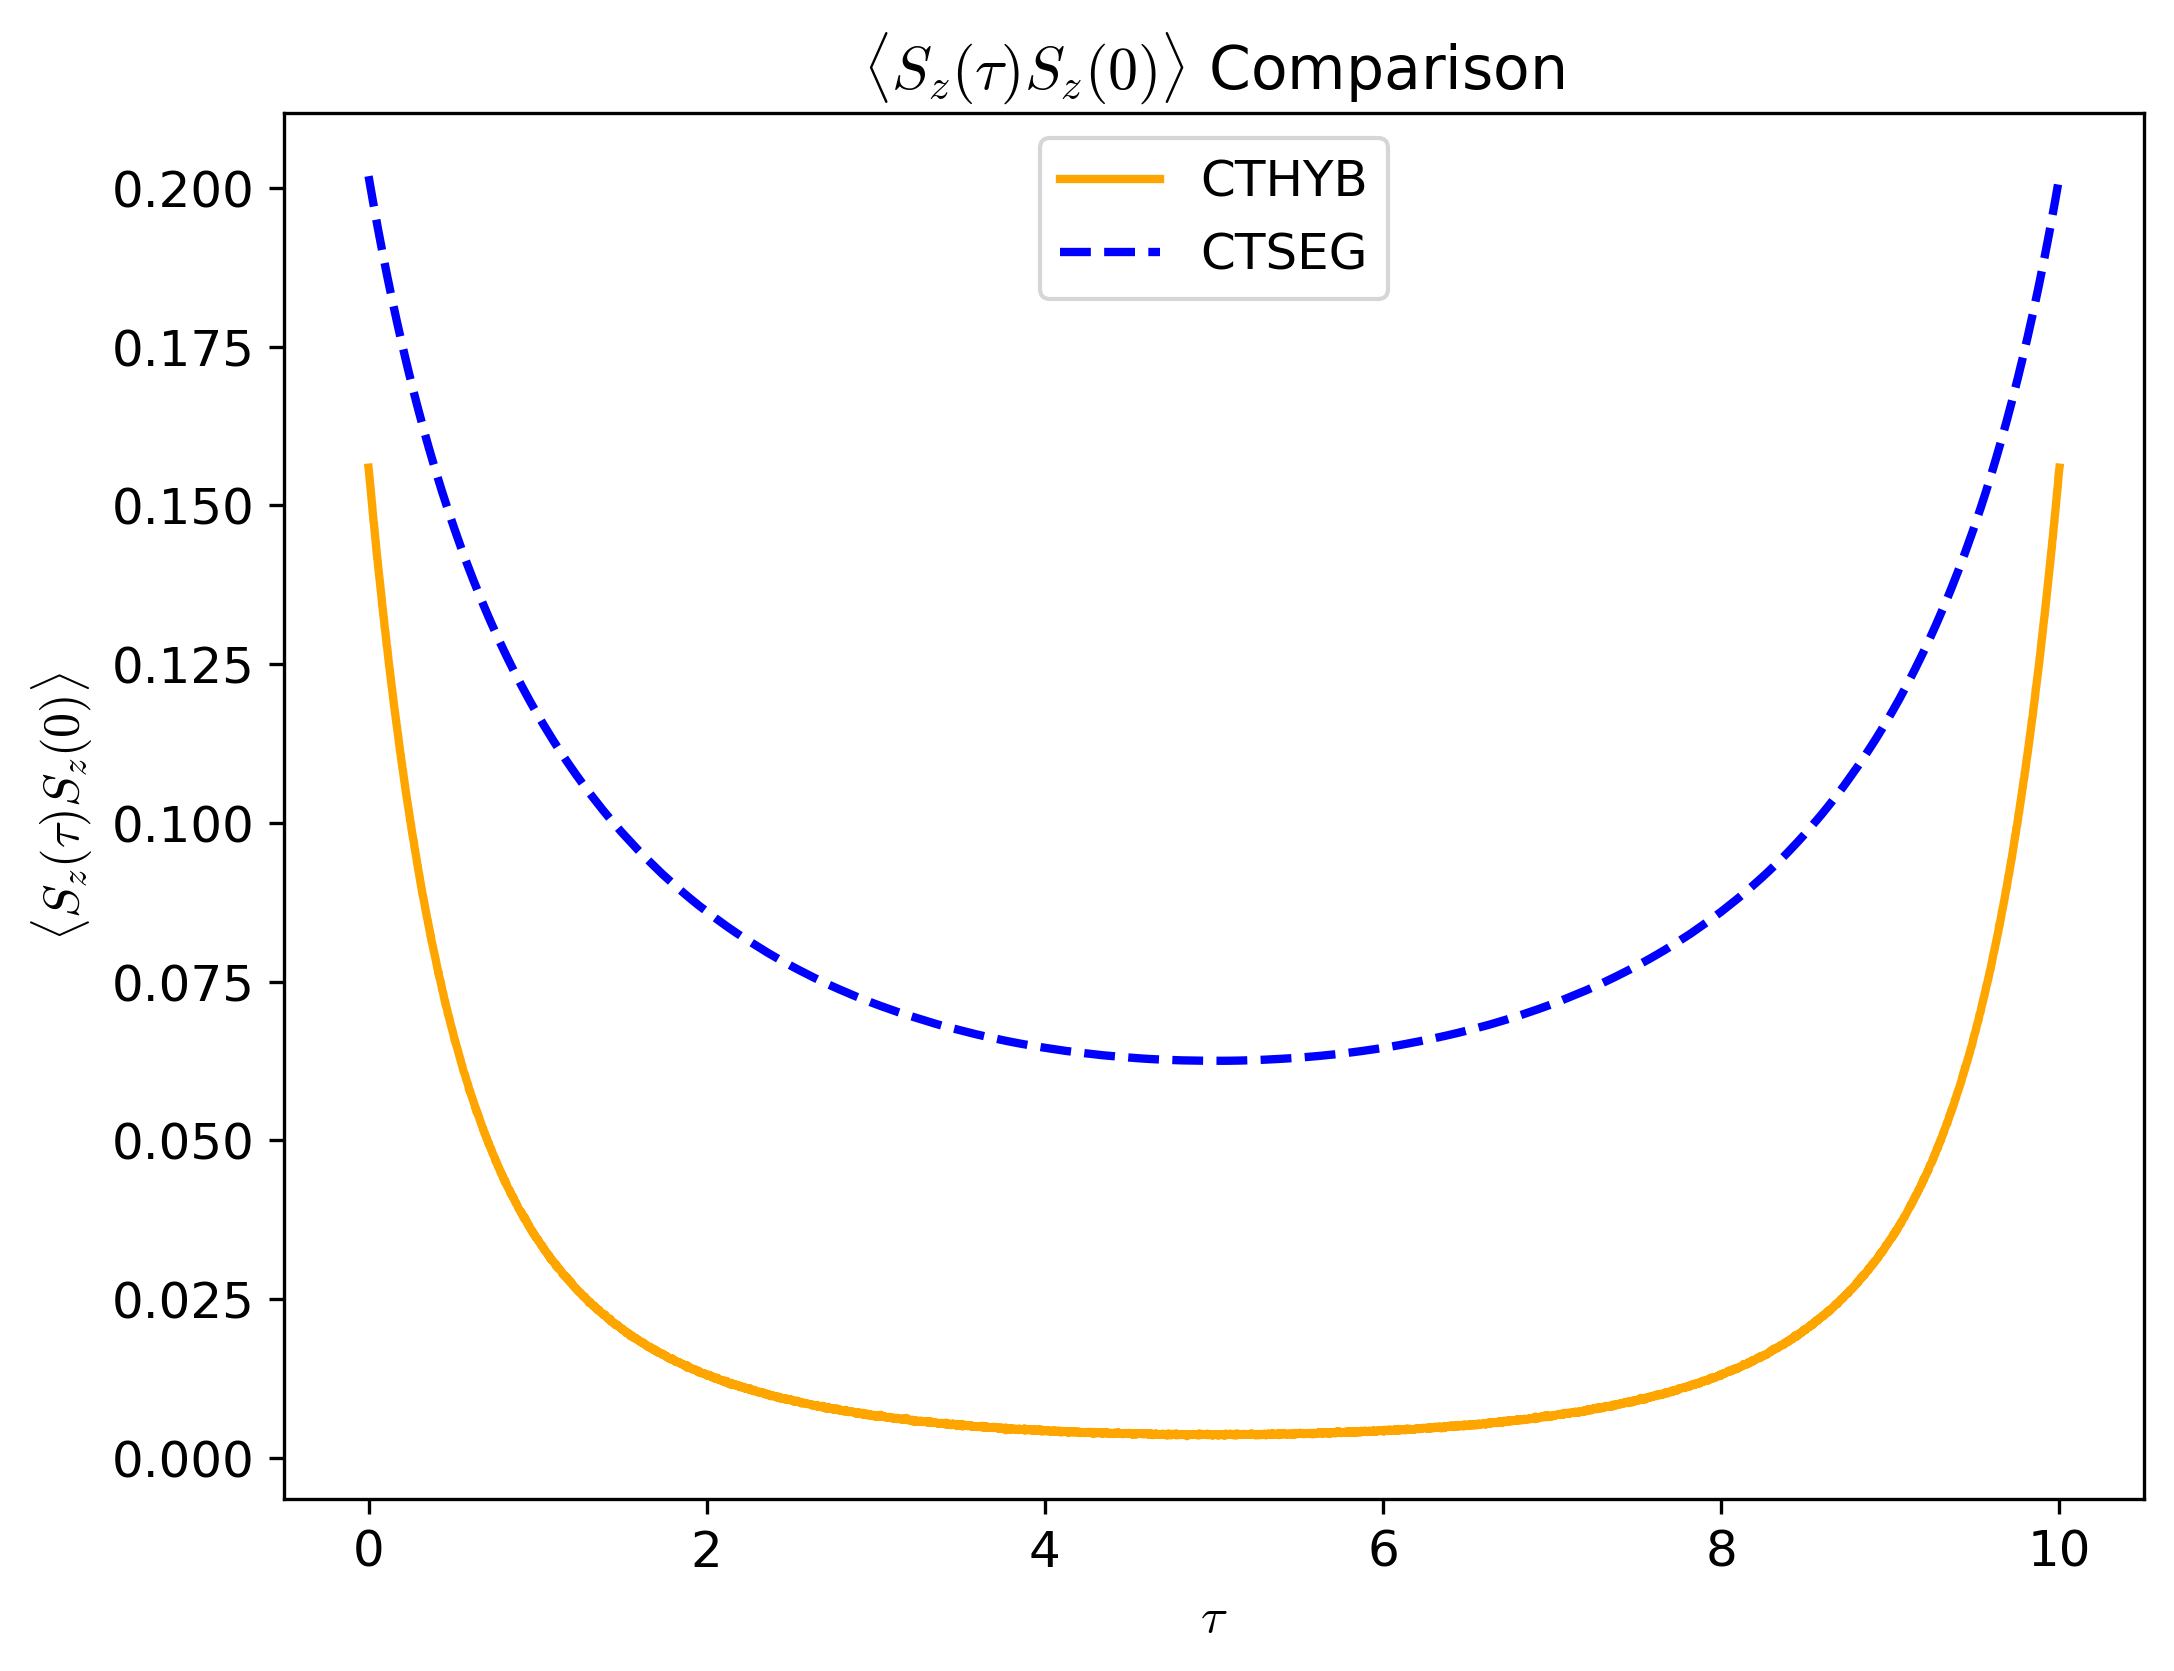

In [10]:
SzSz_seg = 0.25 * (nn_seg['up', 'up'].data[:, 0, 0].real
                 + nn_seg['down', 'down'].data[:, 0, 0].real
                 - nn_seg['up', 'down'].data[:, 0, 0].real
                 - nn_seg['down', 'up'].data[:, 0, 0].real)

tau_seg = np.array([float(t) for t in nn_seg['up', 'up'].mesh])

tau_hyb = np.array([float(t) for t in Sz_hyb.mesh])
SzSz_hyb = Sz_hyb.data.real

plt.figure(figsize=(8, 6))
plt.plot(tau_hyb, SzSz_hyb, color="orange", linewidth=2.0, label="CTHYB")
plt.plot(tau_seg, SzSz_seg, color="blue", linewidth=2.0, label="CTSEG", linestyle="--")
plt.title(r"$\langle S_z(\tau) S_z(0) \rangle$ Comparison")
plt.ylabel(r"$\langle S_z(\tau) S_z(0) \rangle$")
plt.xlabel(r"$\tau$")
plt.legend()
plt.show()


In [5]:
data_loc = "/home/andrewhardy/Documents/Data/CTHYB_Data"
f_cthyb = f"{data_loc}/spin_spin_cthyb_lambda--0.0-U-4.0_b-10.0_nw-1000000_mins-100.h5"
f_ctseg = f"{data_loc}/spin_spin_ctseg_lambda--0.0-U-4.0_b-10.0.h5"

with HDFArchive(f_cthyb, "r") as A:
    G_tau_hyb = A["G_tau"]
    Sz_hyb = A["O_tau"]

with HDFArchive(f_ctseg, "r") as A:
    G_tau_seg = A["G_tau"]
    nn_seg = A["nn_tau"]

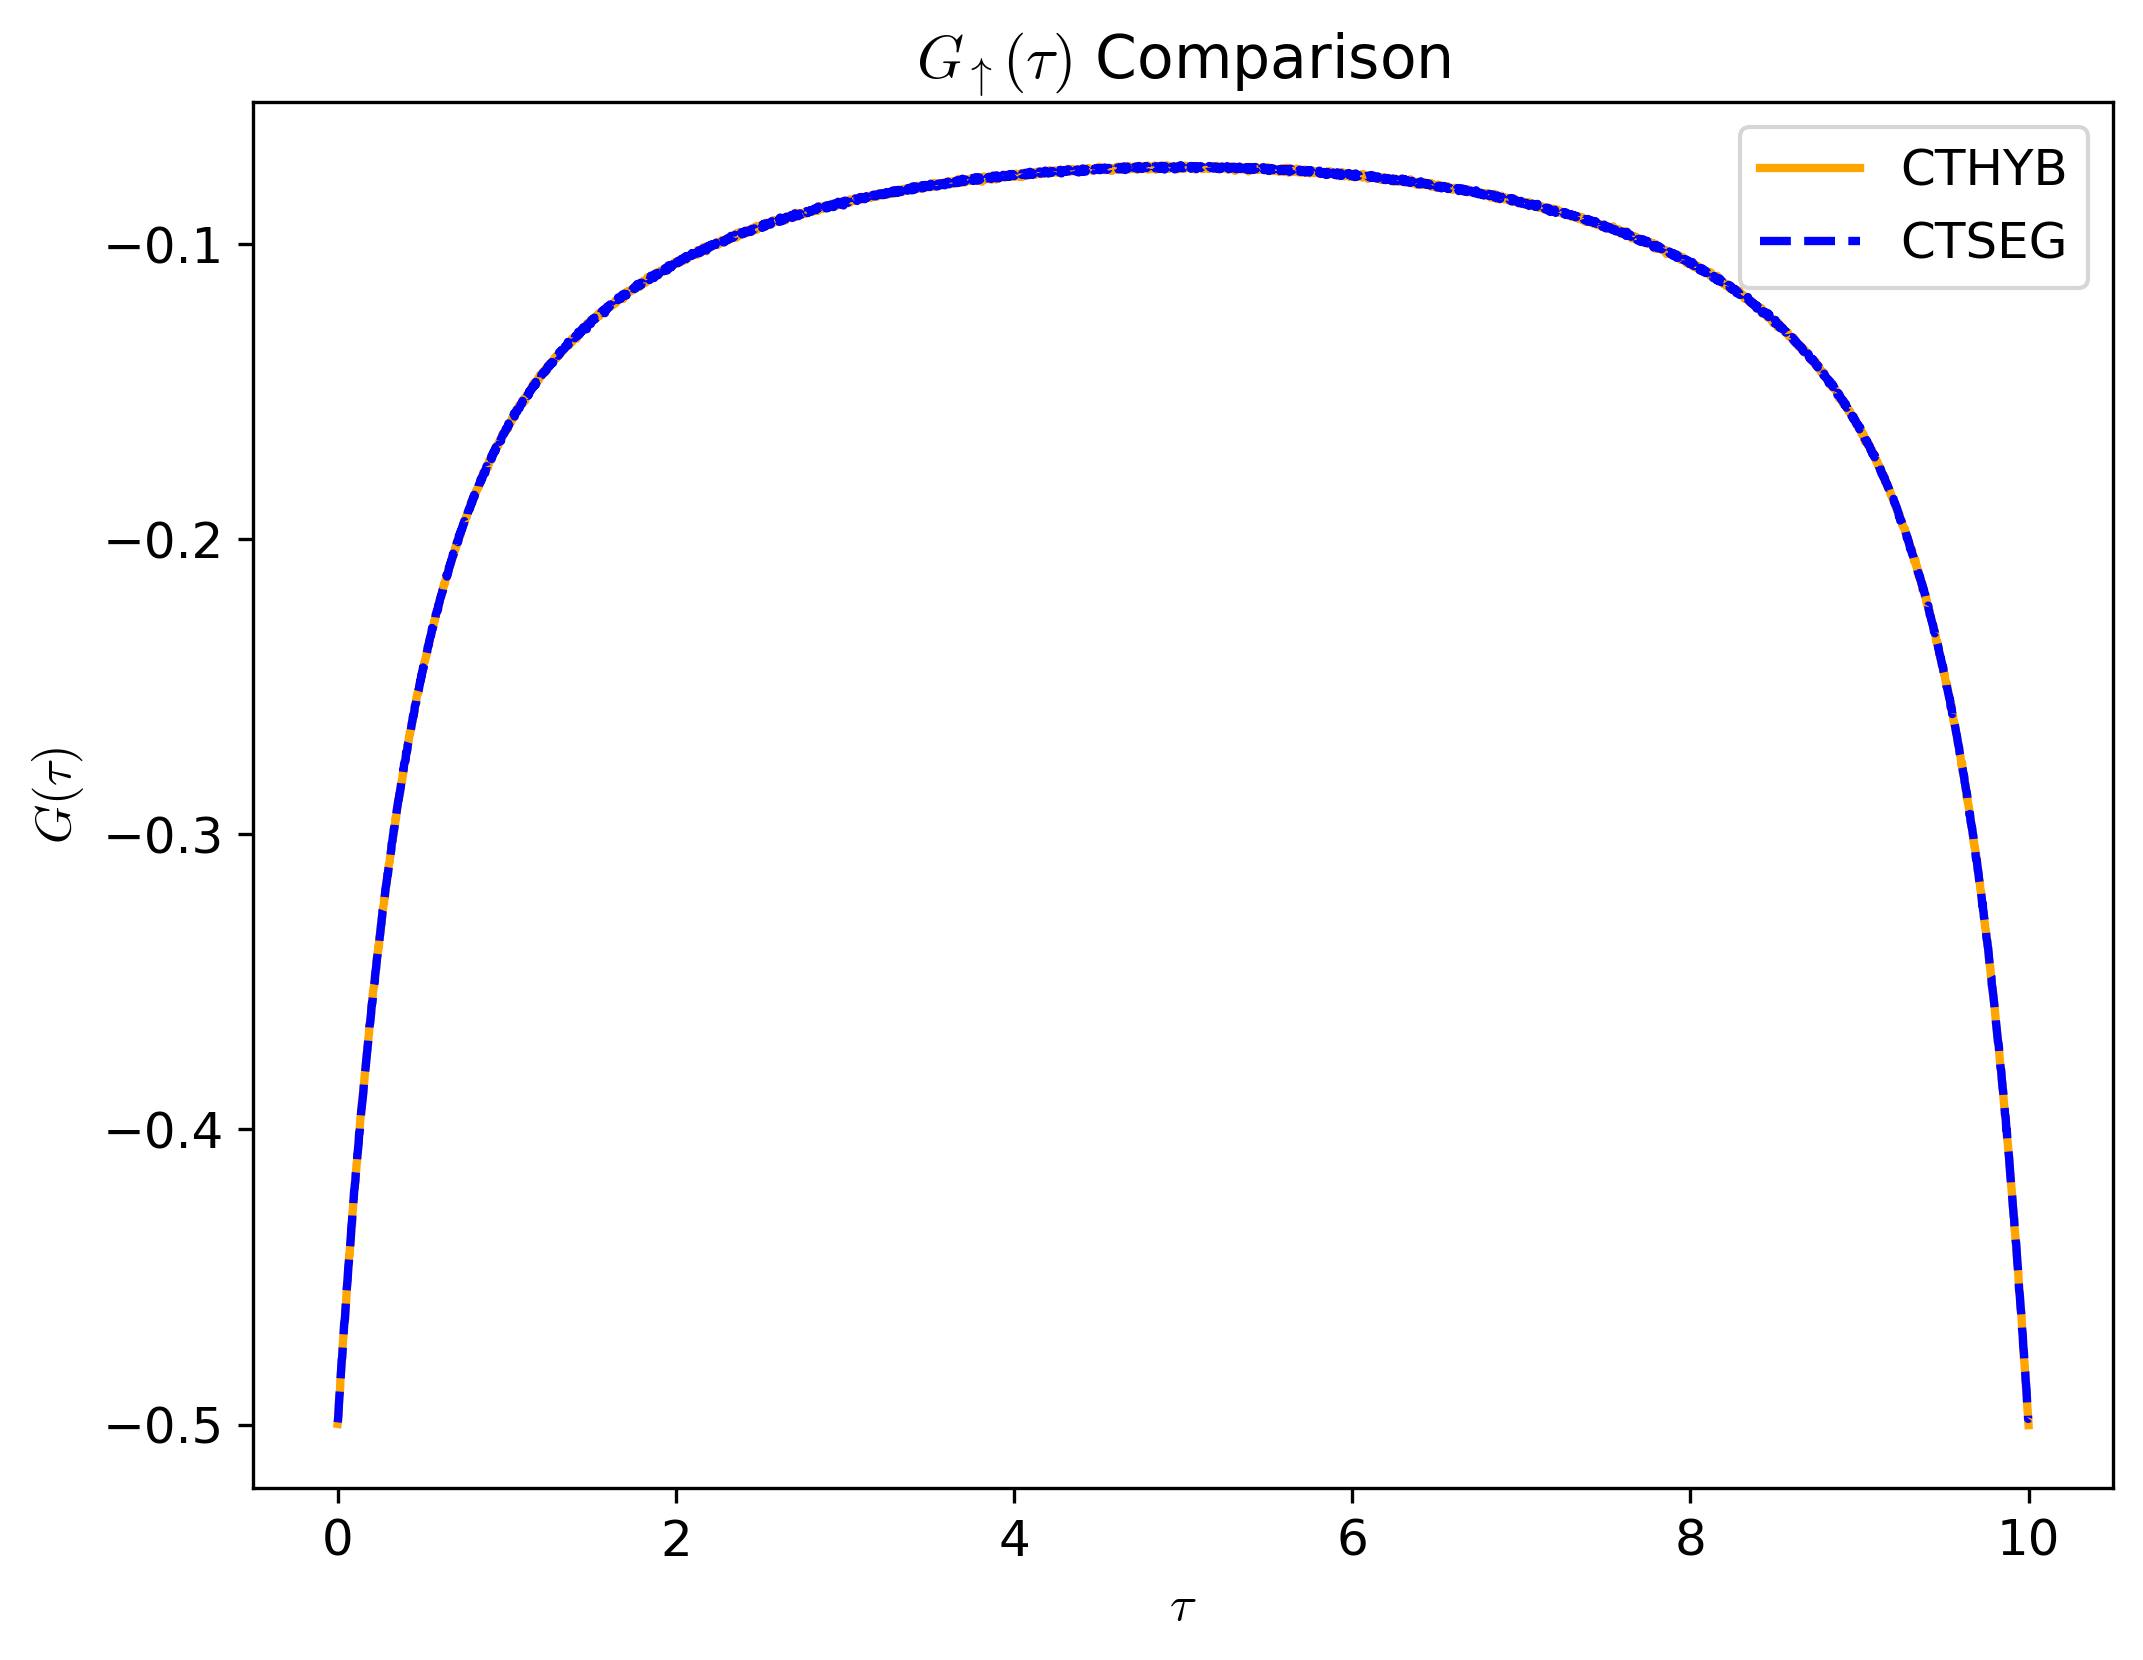

In [6]:
plt.figure(figsize=(8, 6))
oplot(G_tau_hyb["up"].real, color="orange", linewidth=2.0, label="CTHYB")
oplot(G_tau_seg["up"].real, color="blue", linewidth=2.0, label="CTSEG", linestyle="--")
plt.title(r"$G_\uparrow(\tau)$ Comparison")
plt.ylabel(r"$G(\tau)$")
plt.legend()
plt.show()


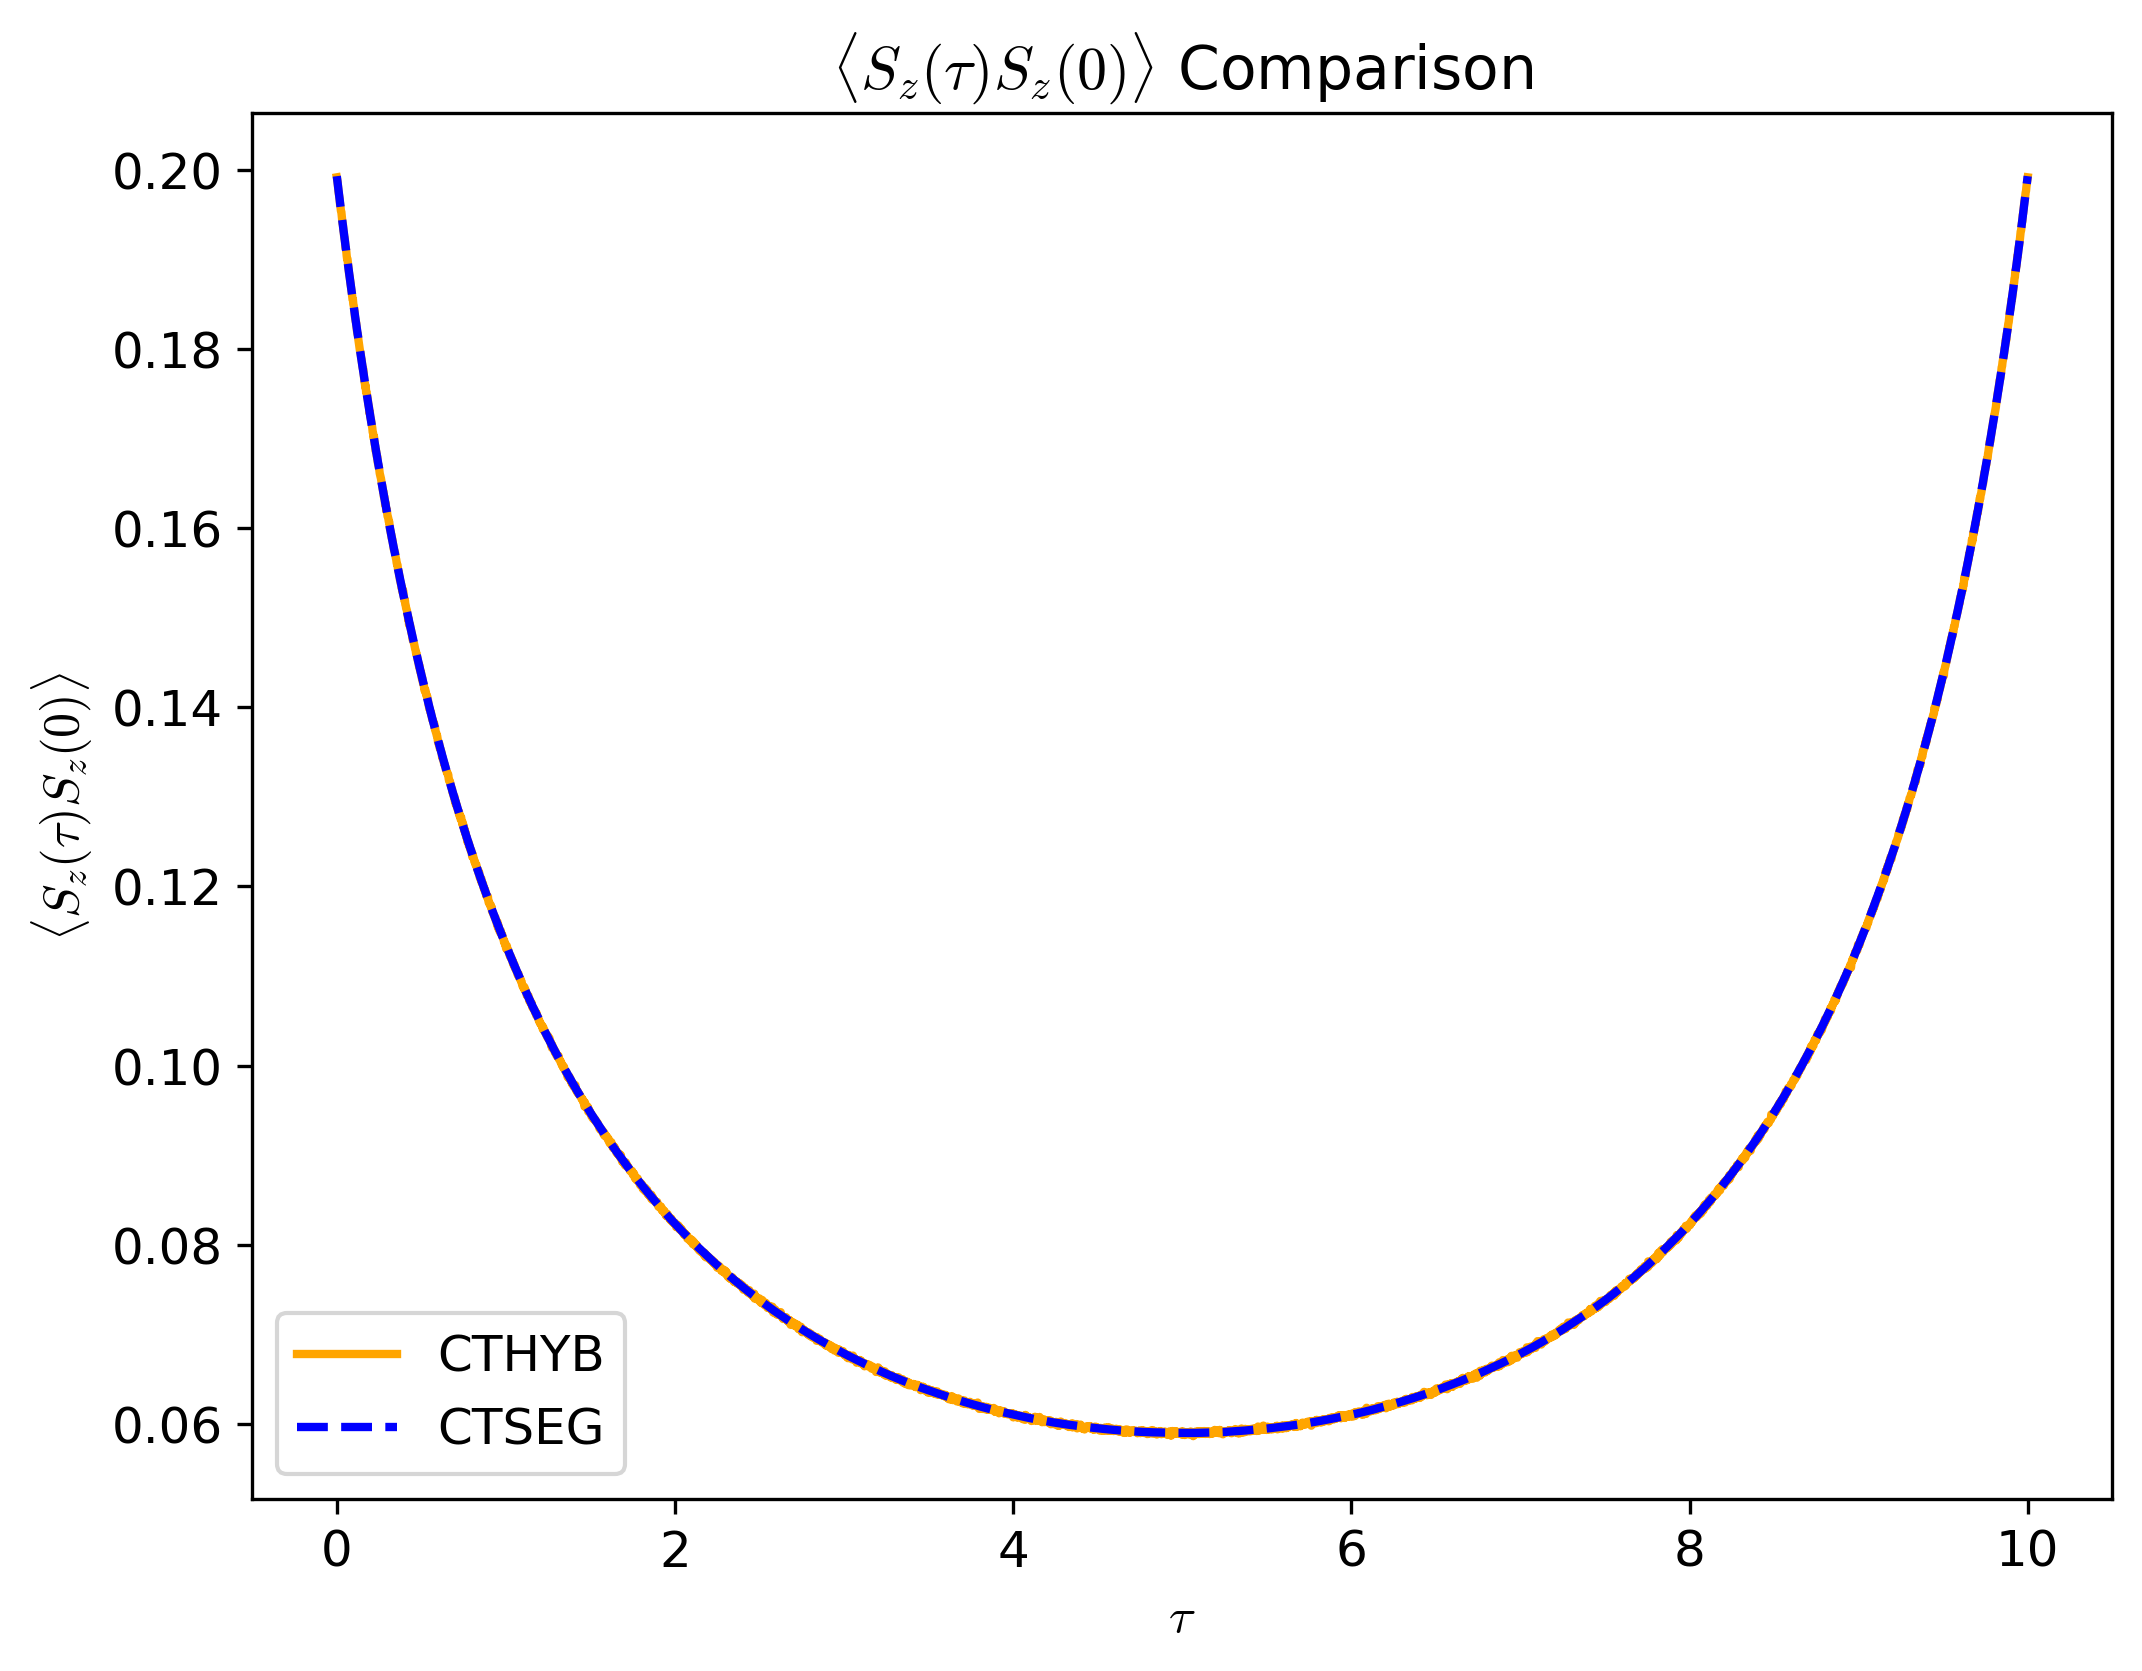

In [7]:
SzSz_seg = 0.25 * (nn_seg['up', 'up'].data[:, 0, 0].real
                 + nn_seg['down', 'down'].data[:, 0, 0].real
                 - nn_seg['up', 'down'].data[:, 0, 0].real
                 - nn_seg['down', 'up'].data[:, 0, 0].real)

tau_seg = np.array([float(t) for t in nn_seg['up', 'up'].mesh])

tau_hyb = np.array([float(t) for t in Sz_hyb.mesh])
SzSz_hyb = Sz_hyb.data.real

plt.figure(figsize=(8, 6))
plt.plot(tau_hyb, SzSz_hyb, color="orange", linewidth=2.0, label="CTHYB")
plt.plot(tau_seg, SzSz_seg, color="blue", linewidth=2.0, label="CTSEG", linestyle="--")
plt.title(r"$\langle S_z(\tau) S_z(0) \rangle$ Comparison")
plt.ylabel(r"$\langle S_z(\tau) S_z(0) \rangle$")
plt.xlabel(r"$\tau$")
plt.legend()
plt.show()